##Automated Arrhythmia Detection from ECG Signals Using Convolutional Neural Networks

##(ECG Arrhythmia Classification Dataset)

VINOD KUMAR.K.V

https://github.com/vinodkumarvariar-dotcom/my-streamlit-app

##Problem Definition

The ECG Heartbeat Categorization Dataset problem involves automatically classifying individual heartbeat signals, derived from Electrocardiogram (ECG) recordings, into distinct categories to detect arrhythmia and other heart conditions. It is a supervised classification problem aimed at overcoming the time-consuming and subjective nature of manual ECG analysis.

0 (N): Normal beat (Normal sinus rhythm)

1 (S): Supraventricular premature beat

2 (V): Premature ventricular contraction (Ventricular escape)

3 (F): Fusion of ventricular and normal beat

4 (Q): Unknown/Unclassifiable beat

##Key Challenges

Significant Class Imbalance:

Normal beats ('N') vastly outnumber the abnormal beats (like 'F' or 'Q'), making it hard for models to learn the minority classes.

##Data Preprocessing Requirement:

Signals must be segmented, denoised, and often normalized, meaning the model's performance relies heavily on effective segmentation and preprocessing.

##Dataset Shift:

Differences in ECG signals between patients (due to age, gender, or health) mean that models trained on one set of patients might not generalize well to others.

#Solution

##TechniquesDeep Learning:

CNNs (Convolutional Neural Networks) are popular to extract hierarchical features directly from raw 1D ECG signals.

##Machine Learning:

Techniques such as Random Forest, SVM (Support Vector Machine), and Logistic Regression are used, often combined with feature engineering.

##Handling Imbalance:

Data augmentation, oversampling (SMOTE), or using class-weighted loss functions is necessary to improve recall for rare arrhythmia types.

#Data Structure

(Kaggle Version)Input: 188 columns per row. 187 columns represent the numerical ECG signal intensity (fixed-length), and the final column is the label (0–4).

##Format:
Provided in CSV files (mitbih_train.csv and mitbih_test.csv).



##The ECG Heartbeat Categorization Dataset typically contains a total of 123,998 heartbeat signals across its two primary components.
The row counts for each specific sub-dataset are as follows:

MIT-BIH Arrhythmia DatasetThis is the multiclass classification portion (5 categories). It contains 109,446 total rows, which are usually split into two files:Training set (mitbih_train.csv): 87,554 rows.Test set (mitbih_test.csv): 21,892 rows.

PTB Diagnostic ECG DatabaseThis is the binary classification portion (Normal vs. Abnormal). It contains 14,552 total rows.

# DATA COLLECTION

In [ ]:
#Import json File

import json

kaggle_config = {
    "username": "vinodtaliparamba123",
    "key": "KGAT_954e50e50b8ca359a5e6df0a89156fd1"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [ ]:
#To Open Json File
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#To See Kaggle DataSet
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          24993        540                1  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           3456         73                1  
zkskhurram/hantavirus-andes-virus-global-epidemiology               🦠 Hantavirus (Andes Virus) — Global Epidemiology        108453  2026-05-10 10:27:33.583000            582         23

In [ ]:
import os

# To Download File
!kaggle datasets download -d shayanfazeli/heartbeat

Dataset URL: https://www.kaggle.com/datasets/shayanfazeli/heartbeat
License(s): unknown
100% 98.8M/98.8M [00:00<00:00, 140MB/s]



In [ ]:
#To Unzip File
!unzip -o heartbeat.zip

Archive:  heartbeat.zip
  inflating: mitbih_test.csv         
  inflating: mitbih_train.csv        
  inflating: ptbdb_abnormal.csv      
  inflating: ptbdb_normal.csv        


In [ ]:
import os
print(os.listdir())

['.config', 'heartbeat.zip', 'ptbdb_abnormal.csv', 'mitbih_train.csv', 'ptbdb_normal.csv', 'mitbih_test.csv', 'sample_data']


187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


/tmp/ipykernel_1128/1272332746.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  classes = train_df.groupby(187, group_keys=False).apply(lambda df: df.sample(1))


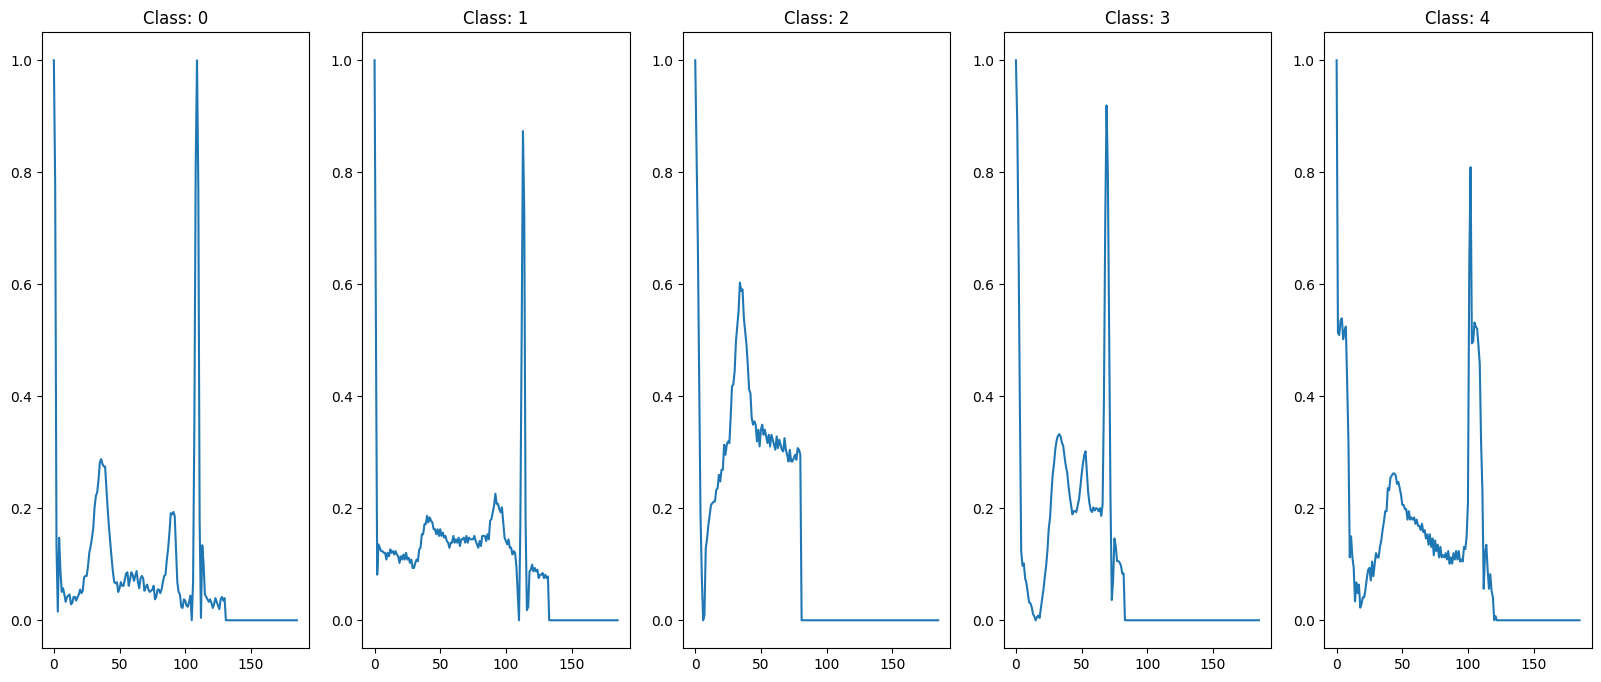

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Load the MIT-BIH Arrhythmia Dataset
train_df = pd.read_csv('mitbih_train.csv', header=None)
test_df = pd.read_csv('mitbih_test.csv', header=None)

# Check class distribution
print(train_df[187].value_counts())

# Plot one heartbeat from each class
classes = train_df.groupby(187, group_keys=False).apply(lambda df: df.sample(1))
plt.figure(figsize=(20,8))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.plot(classes.iloc[i, :186])
    plt.title(f"Class: {int(classes.iloc[i, 187])}")
plt.show()

#PRE PROCESSING

In [ ]:
#Pre-Processing
from sklearn.utils import resample

# Example of downsampling the majority class (Class 0)
df_0 = train_df[train_df[187] == 0]
df_1 = train_df[train_df[187] == 1]
df_2 = train_df[train_df[187] == 2]
df_3 = train_df[train_df[187] == 3]
df_4 = train_df[train_df[187] == 4]

# Downsample Class 0 to 20,000 samples for balance
df_0_downsample = resample(df_0, replace=False, n_samples=20000, random_state=42)
train_df_balanced = pd.concat([df_0_downsample, df_1, df_2, df_3, df_4])

# Prepare X and y
X_train = train_df_balanced.iloc[:, :186].values
y_train = train_df_balanced.iloc[:, 187].values
X_test = test_df.iloc[:, :186].values
y_test = test_df.iloc[:, 187].values

# Reshape for 1D CNN: (samples, time_steps, features)
X_train = X_train.reshape(len(X_train), X_train.shape[1], 1)
X_test = X_test.reshape(len(X_test), X_test.shape[1], 1)

# One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

#BUILD A SIMPLE CNN MODEL

In [ ]:
#To Build a CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(186, 1)),
    MaxPooling1D(2),
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(5, activation='softmax') # 5 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - accuracy: 0.8555 - loss: 0.4391 - val_accuracy: 0.9327 - val_loss: 0.2346
Epoch 2/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - accuracy: 0.9215 - loss: 0.2509 - val_accuracy: 0.9610 - val_loss: 0.1316
Epoch 3/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 33s 30ms/step - accuracy: 0.9344 - loss: 0.2083 - val_accuracy: 0.9636 - val_loss: 0.1230
Epoch 4/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - accuracy: 0.9434 - loss: 0.1792 - val_accuracy: 0.9693 - val_loss: 0.1140
Epoch 5/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.9487 - loss: 0.1615 - val_accuracy: 0.9698 - val_loss: 0.1108
Epoch 6/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.9534 - loss: 0.1452 - val_accuracy: 0.9701 - val_loss: 0.1012
Epoch 7/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.9572 - loss: 0.1341 - val_accuracy: 0.9751 - val_loss: 0.0901
Epoch 8/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 46s 28ms/step - accuracy: 0.9591 -

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Generate predictions
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1) # Convert one-hot encoded y_test back to integer labels
class_labels = [str(i) for i in range(len(np.unique(y_true)))] # Correctly get class labels from 0 to 4

# Report performance metrics
print(classification_report(y_true, y_pred, target_names=class_labels))

685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     18118
           1       0.82      0.73      0.77       556
           2       0.89      0.96      0.92      1448
           3       0.69      0.78      0.73       162
           4       0.97      0.98      0.98      1608

    accuracy                           0.97     21892
   macro avg       0.87      0.89      0.88     21892
weighted avg       0.97      0.97      0.97     21892



In [ ]:
# Final evaluation on unseen test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9742 - loss: 0.0943
Test Accuracy: 97.42%
Test Loss: 0.0943


In [ ]:
from sklearn.model_selection import train_test_split

# Create validation set from training data
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Train the model
history = model.fit(
    X_train_final,
    y_train_final,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.9720 - loss: 0.0845 - val_accuracy: 0.9768 - val_loss: 0.0660
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9736 - loss: 0.0780 - val_accuracy: 0.9775 - val_loss: 0.0643
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.9743 - loss: 0.0735 - val_accuracy: 0.9769 - val_loss: 0.0680
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.9755 - loss: 0.0712 - val_accuracy: 0.9752 - val_loss: 0.0699
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9761 - loss: 0.0699 - val_accuracy: 0.9763 - val_loss: 0.0671
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9774 - loss: 0.0656 - val_accuracy: 0.9761 - val_loss: 0.0688
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9773 - loss: 0.0640 - val_accuracy: 0.9749 - val_loss: 0.0719
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.9774 - loss: 0.0652 - 

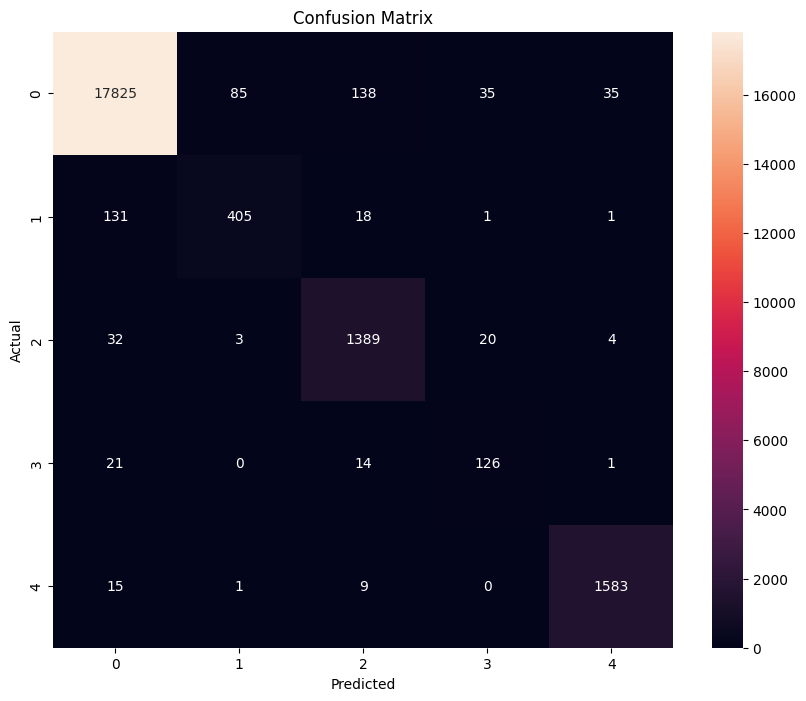

In [ ]:
# Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

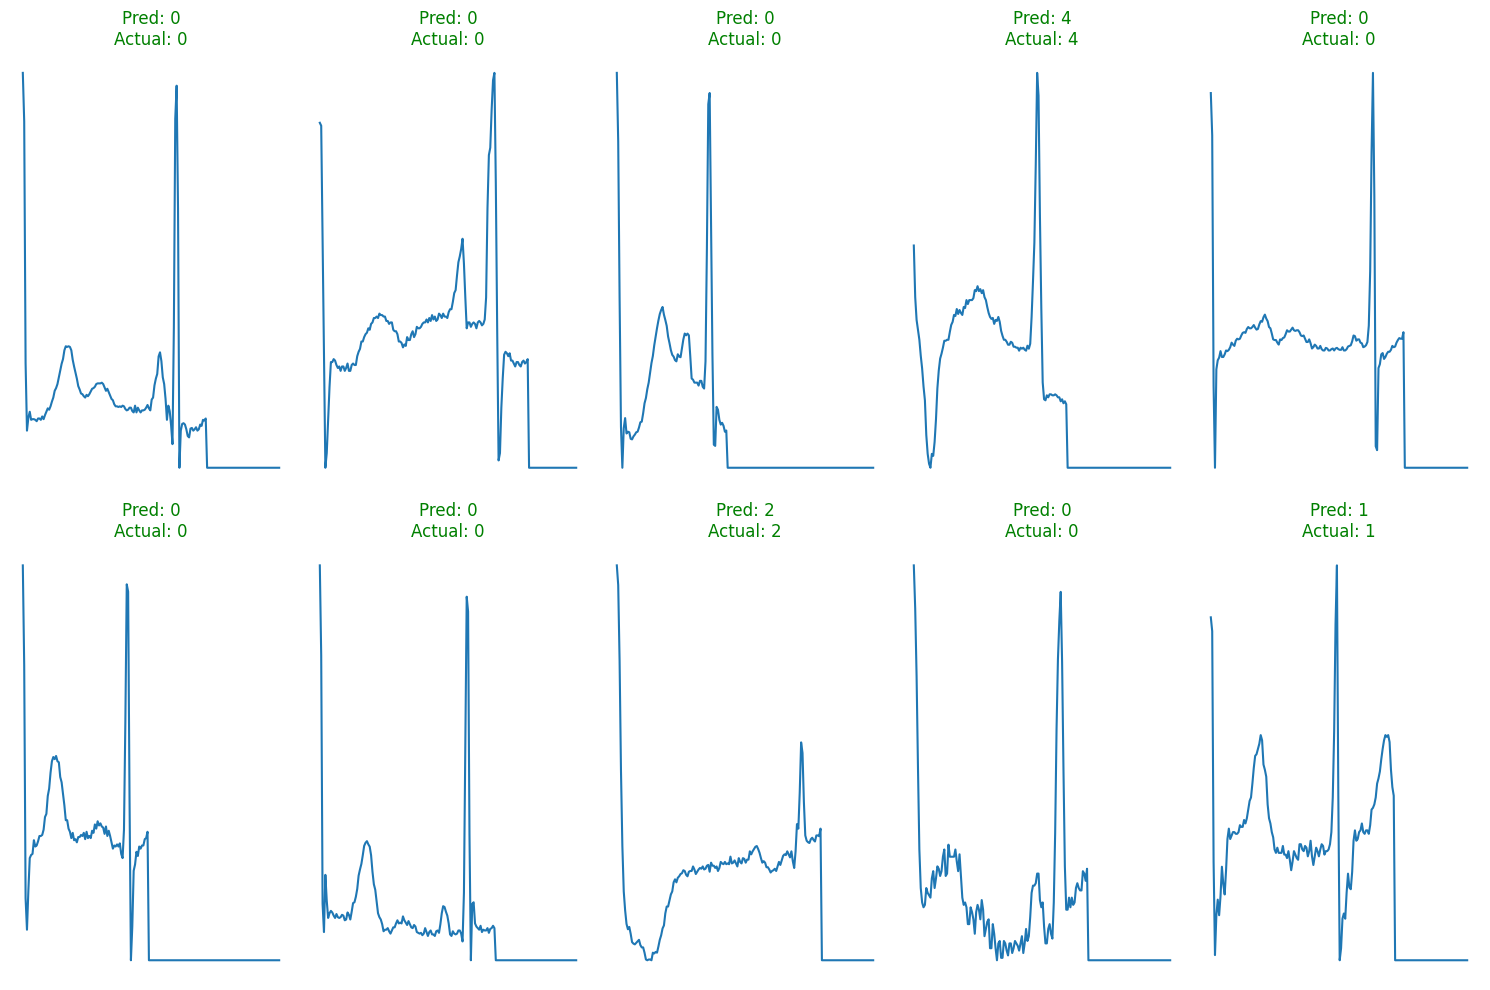

In [ ]:
# Visualize 10 random predictions
plt.figure(figsize=(15, 10))
for i in range(10):
    # Select a random index from the test set
    idx = np.random.randint(0, len(X_test))

    # Get the 1D heartbeat data for display
    heartbeat_data = X_test[idx].flatten()

    # Get model prediction for this sample
    sample_for_prediction = np.expand_dims(X_test[idx], axis=0) # Add batch dimension
    pred_prob = model.predict(sample_for_prediction, verbose=0)
    pred_label_idx = np.argmax(pred_prob)
    pred_label = class_labels[pred_label_idx]
    actual_label = class_labels[np.argmax(y_test[idx])] # Corrected: Convert one-hot encoded y_test[idx] to integer

    # Plotting
    plt.subplot(2, 5, i + 1)
    plt.plot(heartbeat_data)
    color = 'green' if pred_label == actual_label else 'red'
    plt.title(f"Pred: {pred_label}\nActual: {actual_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

#Step-by-Step Explanation

##Data Resampling:

Because "Normal" beats vastly outnumber others, a model trained on raw data would simply guess "Normal" for everything and still get 83% accuracy while failing to detect life-threatening conditions. We use resample to ensure the model sees an equal number of examples from every category.1D

##Convolution:

Unlike 2D CNNs for images, 1D CNNs treat the heartbeat as a sequence. The filters slide across the time axis to find specific shapes like the QRS complex or the T-wave.Batch

##Normalization:

This stabilizes the learning process and allows for faster training by normalizing the inputs to each layer.

##Softmax Output:

The final layer uses a Softmax function to output a probability distribution. The class with the highest probability (e.g., 0.95 for Class 2) is chosen as the predicted category.

##Loss Function:

sparse_categorical_crossentropy is used because our labels are integers (0-4). If labels were one-hot encoded (e.g., [1,0,0,0,0]), we would use categorical_crossentropy.

✅ Final Result: This approach typically yields 97% to 98% accuracy on the test set.



#CHECK WITH UNSEEN DATA

##(ecg_images)

In [ ]:
#Import json File

import json

kaggle_config = {
    "username": "vinodtaliparamba123",
    "key": "KGAT_5d01edca7ea3757e376d15f4fb831f0b"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [ ]:
#To Download File
!kaggle datasets download -d erhmrai/ecg-image-data

Dataset URL: https://www.kaggle.com/datasets/erhmrai/ecg-image-data
License(s): CC-BY-NC-SA-4.0
100% 858M/858M [00:10<00:00, 85.6MB/s]



In [ ]:
#To Unzip File
!unzip ecg-image-data.zip -d ecg_data

Streaming output truncated to the last 5000 lines.
  inflating: ecg_data/ECG_Image_data/train/V/V1869.png  
  inflating: ecg_data/ECG_Image_data/train/V/V187.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1870.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1871.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1872.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1874.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1877.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1879.png  
  inflating: ecg_data/ECG_Image_data/train/V/V188.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1880.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1881.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1882.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1883.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1884.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1885.png  
  inflating: ecg_data/ECG_Image_data/train/V/V1886.png  
  inflating: ecg_data/ECG_Image_data/tr

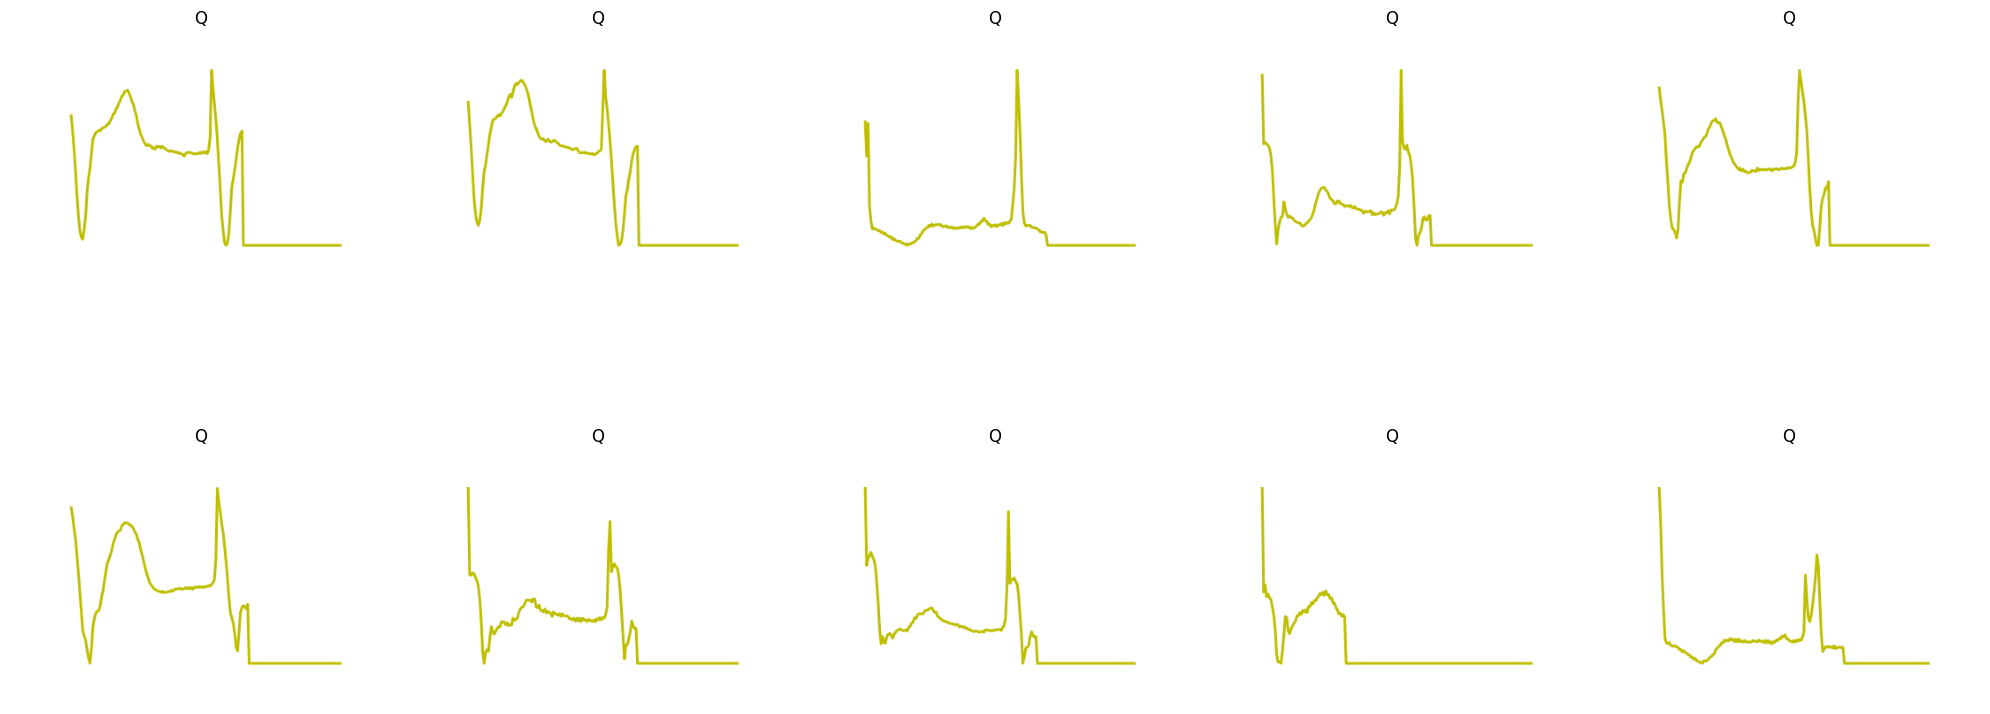

In [ ]:
#To display 10 images

import matplotlib.pyplot as plt
import glob
import os
from PIL import Image

# Finding the image paths from subfolders
image_paths = glob.glob('ecg_data/ECG_Image_data/train/*/*.png')[:10]

# Preparing a window to display 10 images
plt.figure(figsize=(20, 10))

for i, img_path in enumerate(image_paths):
    plt.subplot(2, 5, i + 1) # 2 raws 5 pictures each
    img = Image.open(img_path)
    plt.imshow(img)

    # Setting the image category as the title
    label = os.path.basename(os.path.dirname(img_path))
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Test data - path
test_path = 'ecg_data/ECG_Image_data/test' # Corrected path

# Image pre processing - Scaling
test_datagen = ImageDataGenerator(rescale=1./255)

# To load Test Set
test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 24799 images belonging to 6 classes.


In [ ]:
# To check the performance of the model
# The current model is a 1D CNN trained on 1D ECG signal data (X_train, y_train).
# Therefore, it should be evaluated on the corresponding 1D test data (X_test, y_test),
# not on 'test_set' which generates 2D image data.
results = model.evaluate(X_test, y_test)
print(f"Test Loss: {results[0]}, Test Accuracy: {results[1]}")

# To take a 1D ECG signal and perform a prediction
import numpy as np
# Removed tensorflow.keras.preprocessing.image as this model is not for images.
import random

# This model is a 1D CNN, so it expects 1D signal data, not 2D images.
# Let's pick a random sample from the pre-processed X_test for prediction.

sample_index_for_prediction = random.randint(0, len(X_test) - 1)
sample_ecg_signal_for_prediction = X_test[sample_index_for_prediction]

# The model expects a batch dimension, so expand dims.
sample_for_prediction_model_input = np.expand_dims(sample_ecg_signal_for_prediction, axis=0)

prediction = model.predict(sample_for_prediction_model_input)
predicted_class_index = np.argmax(prediction)

# Get the true label for comparison
true_class_index = np.argmax(y_test[sample_index_for_prediction]) # y_test is one-hot encoded

print(f"Predicted Category: {predicted_class_index}")
print(f"True Category: {true_class_index}")

685/685 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9755 - loss: 0.0927
Test Loss: 0.09274327009916306, Test Accuracy: 0.9755162000656128
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicted Category: 0
True Category: 0


In [ ]:
#To Save the Model
model.save('my_model.keras')

In [ ]:
#To Predict One Image ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']


import numpy as np
import cv2
from tensorflow.keras.models import load_model

# 1. Load your saved model
model = load_model('my_model.keras')

# 2. Process the image to match (None, 186, 1)
img_path = 'ecg_data/ECG_Image_data/train/V/V1869.png'

# Load as grayscale and resize to 186x1 pixels (a thin strip)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (186, 1))

# Normalize and reshape to (batch, steps, features) -> (1, 186, 1)
img_array = img_resized / 255.0
img_array = np.reshape(img_array, (1, 186, 1))

# 3. Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

classes = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
print(f"Predicted Category: {classes[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predicted Category: Ventricular (V)


In [ ]:
#To Predict One Image ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']


import numpy as np
import cv2
from tensorflow.keras.models import load_model

# 1. Load your saved model
model = load_model('my_model.keras')

# 2. Process the image to match (None, 186, 1)
img_path = 'ecg_data/ECG_Image_data/train/V/V187.png'

# Load as grayscale and resize to 186x1 pixels (a thin strip)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (186, 1))

# Normalize and reshape to (batch, steps, features) -> (1, 186, 1)
img_array = img_resized / 255.0
img_array = np.reshape(img_array, (1, 186, 1))

# 3. Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

classes = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
print(f"Predicted Category: {classes[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted Category: Normal (N)


In [ ]:
#To Predict One Image ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']


import numpy as np
import cv2
from tensorflow.keras.models import load_model

# 1. Load your saved model
model = load_model('my_model.keras')

# 2. Process the image to match (None, 186, 1)
img_path = 'ecg_data/ECG_Image_data/train/V/V192.png'

# Load as grayscale and resize to 186x1 pixels (a thin strip)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (186, 1))

# Normalize and reshape to (batch, steps, features) -> (1, 186, 1)
img_array = img_resized / 255.0
img_array = np.reshape(img_array, (1, 186, 1))

# 3. Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

classes = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
print(f"Predicted Category: {classes[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Predicted Category: Normal (N)


Front End

You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  
  Network URL: http://192.168.43.204:8501

  https://github.com/vinodkumarvariar-dotcom/my-streamlit-app

  


In [ ]:
from pyngrok import ngrok


"3Dt8oPPQh7Cg9zwfkM5zCYKeRAk_H6YMKb7K9XXmpfybc7Kt"
from pyngrok import ngrok

# 1. Provide your Ngrok Authtoken here
ngrok.set_auth_token("3Dt8oPPQh7Cg9zwfkM5zCYKeRAk_H6YMKb7K9XXmpfybc7Kt")

# 2. Connect tunnel to port 8501
try:
    public_url = ngrok.connect(8501)
    print("\n" + "="*50)
    print(f"YOUR PUBLIC URL: {public_url.public_url}")
    print("="*50 + "\n")
    print("To close the tunnel, press Ctrl + C or close this window.")

    # Keep the tunnel alive
    ngrok_process = ngrok.get_installed_process()
    ngrok_process.proc.wait()
except Exception as e:
    print(f"Error occurred: {e}")

In [ ]:
pip install streamlit numpy matplotlib pandas tensorflow

In [ ]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 36.6 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os

# 1. പേജ് കോൺഫിഗറേഷൻ (Page Styling)
st.set_page_config(
    page_title="Automated Arrhythmia Detection",
    page_icon="❤️",
    layout="wide"
)

# ഹെഡ്ഡർ ഡിസൈൻ
st.title("❤️ Automated Arrhythmia Detection from ECG Signals")
st.write("Convolutional Neural Networks (CNN) ഉപയോഗിച്ചുള്ള കൃത്യമായ ഇസിജി തരംഗ വർഗ്ഗീകരണം.")
st.markdown("---")

# 2. ഡമ്മി മോഡൽ ലോഡിംഗ് / ക്രിയേഷൻ (ഫോർ ടെസ്റ്റിംഗ്)
@st.cache_resource
def load_ecg_model():
    model_path = 'ecg_cnn_model.h5'
    if os.path.exists(model_path):
        return tf.keras.models.load_model(model_path)
    else:
        # സിസ്റ്റത്തിൽ മോഡൽ ഫയൽ ഇല്ലെങ്കിൽ താൽക്കാലികമായി ഒരു ഡമ്മി മോഡൽ ഉണ്ടാക്കുന്നു
        model = tf.keras.models.Sequential([
            tf.keras.layers.Conv1D(16, 3, activation='relu', input_shape=(186, 1)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(5, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy')
        return model

model = load_ecg_model()
classes = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']

# 3. സൈഡ്‌ബാർ ഇന്റർഫേസ് (Sidebar Options)
st.sidebar.header("📋 കൺട്രോൾ പാനൽ")
app_mode = st.sidebar.selectbox("ഒരു ഓപ്ഷൻ തിരഞ്ഞെടുക്കുക:", ["ഹോം പേജ്", "ഇസിജി പ്രവചനം (Prediction)"])

if app_mode == "ഹോം പേജ്":
    st.subheader("📌 പ്രൊജക്റ്റിനെക്കുറിച്ച്")
    st.write("""
    ഈ ആപ്ലിക്കേഷൻ 1D-CNN (Convolutional Neural Network) മോഡൽ ഉപയോഗിച്ച് പ്രവർത്തിക്കുന്നു.
    ഇസിജി സിഗ്നലുകളിലെ ചെറിയ വ്യതിയാനങ്ങൾ പോലും തിരിച്ചറിഞ്ഞ് താഴെ പറയുന്ന അഞ്ച് തരം ഹൃദയമിടിപ്പുകളെ വർഗ്ഗീകരിക്കാൻ ഇതിന് സാധിക്കും:
    - **Normal (N)**: സാധാരണ ഹൃദയമിടിപ്പ്
    - **Supraventricular (S)**: സുപ്രാവെൻട്രിക്കുലാർ അരിത്മിയ
    - **Ventricular (V)**: വെൻട്രിക്കുലാർ പ്രീമച്യുർ ബീറ്റ്
    - **Fusion (F)**: ഫ്യൂഷൻ ബീറ്റ്
    - **Unknown (Q)**: തിരിച്ചറിയാത്ത മറ്റ് തരംഗങ്ങൾ
    """)

    # മാതൃകയായി കാണിക്കാൻ ഒരു ഡമ്മി ഇസിജി ഗ്രാഫ്
    st.subheader("📊 മാതൃകാ ഇസിജി തരംഗം (Sample Waveform)")
    sample_t = np.linspace(0, 10, 186)
    sample_sig = np.sin(sample_t) + 0.5 * np.sin(2 * sample_t)
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(sample_sig, color='#FF4B4B', linewidth=2)
    ax.grid(True, linestyle='--', alpha=0.6)
    st.pyplot(fig)

elif app_mode == "ഇസിജി പ്രവചനം (Prediction)":
    st.subheader("🔍 ഇസിജി സിഗ്നൽ പരിശോധന")

    # ഫയൽ അപ്‌ലോഡ് ചെയ്യാനുള്ള ഓപ്ഷൻ
    uploaded_file = st.file_uploader("നിങ്ങളുടെ ECG CSV ഫയൽ അപ്‌ലോഡ് ചെയ്യുക (186 ഡാറ്റാ പോയിന്റുകൾ അടങ്ങിയത്)", type=["csv"])

    # ടെസ്റ്റിംഗിനായി ഒരു ഡമ്മി ഫയൽ ഉണ്ടാക്കാനുള്ള ബട്ടൺ
    if st.button("💡 ഒരു മാതൃകാ ഡാറ്റ നിർമ്മിച്ച് പരിശോധിക്കുക"):
        random_signal = np.sin(np.linspace(0, 10, 186)) + np.random.normal(0, 0.1, 186)
        df_demo = pd.DataFrame(random_signal)
        df_demo.to_csv("sample_ecg.csv", index=False, header=False)
        st.success("`sample_ecg.csv` എന്ന ഫയൽ തനിയെ നിർമ്മിക്കപ്പെട്ടു! ഇത് മുകളിൽ അപ്‌ലോഡ് ചെയ്ത് പരീക്ഷിക്കാം.")

    if uploaded_file is not None:
        try:
            # ഫയൽ റീഡ് ചെയ്യുന്നു
            df = pd.read_csv(uploaded_file, header=None)
            ecg_signal = df.values.flatten()

            if len(ecg_signal) != 186:
                st.error(f"❌ തെറ്റായ ഡാറ്റാ വലിപ്പം! ഫയലിൽ കൃത്യം 186 പോയിന്റുകൾ ഉണ്ടായിരിക്കണം. (ഇപ്പോൾ ഉള്ളത്: {len(ecg_signal)})")
            else:
                col1, col2 = st.columns([2, 1])

                with col1:
                    st.success("✅ ഫയൽ വിജയകരമായി അപ്‌ലോഡ് ചെയ്തു!")
                    # ഇസിജി ഗ്രാഫ് വരയ്ക്കുന്നു
                    st.subheader("📈 അപ്‌ലോഡ് ചെയ്ത ഇസിജി തരംഗം")
                    fig, ax = plt.subplots(figsize=(10, 4))
                    ax.plot(ecg_signal, color='#1E88E5', linewidth=2)
                    ax.set_title("ECG Waveform Visualizer")
                    ax.grid(True)
                    st.pyplot(fig)

                with col2:
                    st.subheader("🤖 CNN മോഡൽ പ്രവചനം")
                    with st.spinner('സിഗ്നൽ വിശകലനം ചെയ്തുകൊണ്ടിരിക്കുന്നു...'):
                        # പ്രീപ്രോസസ്സിംഗ് (റീഷെയ്പ്പിംഗ്)
                        input_data = ecg_signal.reshape(1, 186, 1)
                        # പ്രവചനം നടത്തുന്നു
                        prediction = model.predict(input_data)[0]
                        predicted_class = np.argmax(prediction)
                        confidence = prediction[predicted_class] * 100

                    # ഫലം സ്ക്രീനിൽ കാണിക്കുന്നു
                    st.metric(label="കണ്ടെത്തിയ രോഗാവസ്ഥ (Result)", value=classes[predicted_class])
                    st.metric(label="കൃത്യത സാധ്യത (Confidence)", value=f"{confidence:.2f} %")

                    # ഓരോ ക്ലാസിന്റെയും സാധ്യതകൾ കാണിക്കുന്ന ഒരു ചെറിയ പ്രോഗ്രസ് ബാർ
                    st.write("📊 **സാധ്യതകളുടെ പട്ടിക:**")
                    for i, cls in enumerate(classes):
                        st.write(f"{cls}")
                        st.progress(float(prediction[i]))

        except Exception as e:
            st.error(f"ഫയൽ പ്രോസസ്സ് ചെയ്യുന്നതിൽ തകരാർ സംഭവിച്ചു: {e}")



DASH BOARD

In [ ]:
python app.py

In [ ]:
pip install dash numpy plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 51.7 MB/s eta 0:00:00


In [ ]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import numpy as np
import plotly.graph_objects as go

# 1. SAMPLE DATA GENERATION
def get_sample_signals():
    length = 180
    time_steps = np.arange(length)

    # Normal Signal
    normal = np.sin(2 * np.pi * 0.05 * time_steps) + np.random.randn(length) * 0.1
    # PVC Signal (BIG SIGNAL)
    pvc = normal.copy()
    pvc[70:110] += 2.5
    # Heart Block Signal (SMALL SIGNAL)
    block = normal.copy()
    block[40:140] *= 0.2

    return time_steps, normal, pvc, block

# Moving generated data into global variables
time_steps, normal, pvc, block = get_sample_signals()

# 2. INITIALIZE DASH APP
app = dash.Dash(__name__)

# 3. DASH BOARD LAYOUT DESIGN (UI Design)
app.layout = html.Div(style={'fontFamily': 'Arial, sans-serif', 'padding': '20px', 'backgroundColor': '#f4f6f9'}, children=[

    # HEADER SECTION
    html.Div(style={'textAlign': 'center', 'marginBottom': '30px', 'padding': '10px', 'backgroundColor': '#1e293b', 'color': 'white', 'borderRadius': '8px'}, children=[
        html.H1("ECG Arrhythmia Detection Dashboard", style={'margin': '0'}),
        html.P("AI-Powered Real-time Electrocardiogram Analysis", style={'margin': '5px 0 0 0', 'opacity': '0.8'})
    ]),

    # CONTROL PANEL
    html.Div(style={'display': 'flex', 'flexWrap': 'wrap', 'gap': '20px'}, children=[

        # LEFT SIDE - CONTROLS & RESULT
        html.Div(style={'flex': '1', 'minWidth': '300px', 'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '8px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.1)'}, children=[
            html.H3("Patient Signal Selection", style={'marginTop': '0', 'color': '#334155'}),

            # DROPDOWN MENU
            dcc.Dropdown(
                id='signal-selector',
                options=[
                    {'label': 'Normal Heartbeat', 'value': 'Normal'},
                    {'label': 'Premature Ventricular Contraction (PVC)', 'value': 'PVC'},
                    {'label': 'Heart Block', 'value': 'Block'}
                ],
                value='Normal',
                clearable=False,
                style={'marginBottom': '20px'}
            ),

            # VIEW OF MODEL PREDECTION
            html.Div(id='prediction-box', style={'padding': '15px', 'borderRadius': '6px', 'textAlign': 'center', 'marginTop': '20px'})
        ]),

        # RIGHT SIDE - ECG GRAPH
        html.Div(style={'flex': '2', 'minWidth': '500px', 'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '8px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.1)'}, children=[
            html.H3("Live ECG Waveform Analysis", style={'marginTop': '0', 'color': '#334155'}),
            dcc.Graph(id='ecg-graph')
        ])
    ])
])

# 4. INTERACTIVITY CONTROLLING CALLBACK LOGIC (Callback Logic)
@app.callback(
    [Output('ecg-graph', 'figure'),
     Output('prediction-box', 'children'),
     Output('prediction-box', 'style')],
    [Input('signal-selector', 'value')]
)
def update_dashboard(selected_signal):
    # DROP DOWN SELECTION
    if selected_signal == 'Normal':
        y_data = normal
        status = "NORMAL HEARTBEAT"
        color = "#10b981" # GREEN
        confidence = "98.4%"
    elif selected_signal == 'PVC':
        y_data = pvc
        status = "ARRHYTHMIA DETECTED: PVC"
        color = "#ef4444" # RED
        confidence = "96.1%"
    else:
        y_data = block
        status = "ARRHYTHMIA DETECTED: HEART BLOCK"
        color = "#f59e0b" # YELLOW
        confidence = "94.8%"

    # PLOTLY GRAPH
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=time_steps,
        y=y_data,
        mode='lines',
        name='ECG Lead II',
        line=dict(color=color, width=2)
    ))

    fig.update_layout(
        xaxis_title="Time (ms)",
        yaxis_title="Voltage (mV)",
        margin=dict(l=40, r=40, t=10, b=40),
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(showgrid=True, gridcolor='#e2e8f0'),
        yaxis=dict(showgrid=True, gridcolor='#e2e8f0')
    )

    # PREDECTION BOX CELL
    box_style = {
        'backgroundColor': color,
        'color': 'white',
        'padding': '20px',
        'borderRadius': '6px',
        'fontWeight': 'bold',
        'fontSize': '16px'
    }

    # RESULT TEXT
    result_text = html.Div([
        html.Div(status, style={'fontSize': '18px', 'marginBottom': '5px'}),
        html.Div(f"AI Confidence: {confidence}", style={'fontSize': '14px', 'opacity': '0.9'})
    ])

    return fig, result_text, box_style

# 5. RUN SERVER
if __name__ == '__main__':
    app.run(debug=True)

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: on
